# The Final Inversion — Companion Notebook

**Paper:** *The Final Inversion: Ontological Mathematics, the Universal Stack, and the Shadow of Computation within SHA-256*  
**Author:** Dean A. Kulik  
**Date:** March 2026  

---

## Purpose

This notebook turns the paper into an executable companion. It does **three** things:

1. formalizes the SHA-256 die as a state machine,
2. verifies the paper's key local claims directly in code,
3. separates **directly testable statements** from higher-level interpretive claims.

The notebook is intentionally centered on the **single-block die** so the local geometry of the round function stays visible.

---

## What is implemented here

We directly instrument and test:

- the standard SHA-256 round recurrence,
- the **North Bridge / South Bridge** split,
- the **Sziklai seam coupling** at the `a` and `e` registers,
- the **NOP backbone** and round-0 displacement identity,
- the **nilpotent shift backbone**,
- the **two-seam controllability** claim,
- the **prime-root rail** derivations for `H0` and `K`,
- round-wise **carry-channel** statistics,
- a basic **diffusion / avalanche** experiment.

---

## Read discipline

The paper mixes structural math, executable claims, and ontological interpretation.  
This notebook keeps those layers distinct:

- **verified**: exact equalities and computed invariants,
- **illustrated**: plots, tables, and local support measures,
- **interpretive**: prose bridges that are not independent mathematical proofs.

---

## Sample policy

All core proofs are demonstrated on `b"abc"` first, then checked against a small message suite.


In [1]:

# ============================================================
# CONFIGURATION + IMPORTS
# ============================================================

from __future__ import annotations

import hashlib
import math
import struct
from dataclasses import dataclass
from decimal import Decimal, getcontext
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

M32 = 0xFFFFFFFF
SAMPLE_MESSAGE = b"abc"
TEST_MESSAGES = [
    b"",
    b"abc",
    b"hello",
    b"Nexus",
    bytes(range(32)),
    b"A" * 55,  # still one block after padding boundary handling
]

# FIPS initial rails
STD_H = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

STD_K = [
    0x428A2F98,0x71374491,0xB5C0FBCF,0xE9B5DBA5,0x3956C25B,0x59F111F1,0x923F82A4,0xAB1C5ED5,
    0xD807AA98,0x12835B01,0x243185BE,0x550C7DC3,0x72BE5D74,0x80DEB1FE,0x9BDC06A7,0xC19BF174,
    0xE49B69C1,0xEFBE4786,0x0FC19DC6,0x240CA1CC,0x2DE92C6F,0x4A7484AA,0x5CB0A9DC,0x76F988DA,
    0x983E5152,0xA831C66D,0xB00327C8,0xBF597FC7,0xC6E00BF3,0xD5A79147,0x06CA6351,0x14292967,
    0x27B70A85,0x2E1B2138,0x4D2C6DFC,0x53380D13,0x650A7354,0x766A0ABB,0x81C2C92E,0x92722C85,
    0xA2BFE8A1,0xA81A664B,0xC24B8B70,0xC76C51A3,0xD192E819,0xD6990624,0xF40E3585,0x106AA070,
    0x19A4C116,0x1E376C08,0x2748774C,0x34B0BCB5,0x391C0CB3,0x4ED8AA4A,0x5B9CCA4F,0x682E6FF3,
    0x748F82EE,0x78A5636F,0x84C87814,0x8CC70208,0x90BEFFFA,0xA4506CEB,0xBEF9A3F7,0xC67178F2,
]

def hex32(x: int) -> str:
    return f"0x{x & M32:08x}"

def show_df(rows, title: str = ""):
    if title:
        print(title)
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

print("Ready.")
print("Sample message:", SAMPLE_MESSAGE)


Matplotlib is building the font cache; this may take a moment.


Ready.
Sample message: b'abc'


## 1. Core SHA-256 machinery

We use the standard SHA-256 operators.

For a round state

$$
x_r =
\begin{bmatrix}
a_r & b_r & c_r & d_r & e_r & f_r & g_r & h_r
\end{bmatrix}^\top,
$$

the paper's bridge split is the classical decomposition

$$
T1_r = h_r + \Sigma_1(e_r) + \mathrm{Ch}(e_r,f_r,g_r) + K_r + W_r \pmod{2^{32}},
$$

$$
T2_r = \Sigma_0(a_r) + \mathrm{Maj}(a_r,b_r,c_r) \pmod{2^{32}}.
$$

Then the two active seam updates are

$$
a_{r+1} = T1_r + T2_r \pmod{2^{32}},
\qquad
e_{r+1} = d_r + T1_r \pmod{2^{32}},
$$

while the remaining six lanes shift.


In [2]:

# ============================================================
# CORE OPERATORS
# ============================================================

def rotr(x: int, n: int) -> int:
    return ((x >> n) | ((x << (32 - n)) & M32)) & M32

def shr(x: int, n: int) -> int:
    return (x >> n) & M32

def Sigma0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def Ch(x: int, y: int, z: int) -> int:
    return ((x & y) ^ ((~x) & z)) & M32

def Maj(x: int, y: int, z: int) -> int:
    return ((x & y) ^ (x & z) ^ (y & z)) & M32

def bit_count32(x: int) -> int:
    return (x & M32).bit_count()

def pad_one_block(message: bytes) -> bytes:
    if len(message) > 55:
        raise ValueError("This notebook's local die analysis expects a one-block message (<= 55 bytes).")
    ml = len(message) * 8
    data = bytearray(message)
    data.append(0x80)
    while len(data) % 64 != 56:
        data.append(0)
    data += ml.to_bytes(8, "big")
    if len(data) != 64:
        raise ValueError("Padding produced more than one block.")
    return bytes(data)

def schedule_from_block(block: bytes) -> List[int]:
    W = list(struct.unpack(">16I", block))
    for t in range(16, 64):
        W.append((sigma1(W[t - 2]) + W[t - 7] + sigma0(W[t - 15]) + W[t - 16]) & M32)
    return W

def digest_from_state(final_state: List[int]) -> str:
    return "".join(f"{w:08x}" for w in final_state)

@dataclass
class RoundTrace:
    round_index: int
    state_in: Tuple[int, int, int, int, int, int, int, int]
    W: int
    K: int
    T1: int
    T2: int
    state_out: Tuple[int, int, int, int, int, int, int, int]
    carry_T1: int
    carry_a: int
    carry_e: int

def carry_count_pair(x: int, y: int) -> int:
    # Carry count across the 32 bit positions for x + y.
    carries = 0
    c = 0
    for i in range(32):
        xi = (x >> i) & 1
        yi = (y >> i) & 1
        c_out = (xi & yi) | (xi & c) | (yi & c)
        carries += c_out
        c = c_out
    return int(carries)

def add_many_with_carry_counts(*args: int) -> Tuple[int, int]:
    total = 0
    total_carries = 0
    for arg in args:
        total_carries += carry_count_pair(total, arg)
        total = (total + arg) & M32
    return total, total_carries

def sha256_compress_trace_one_block(message: bytes) -> Dict[str, object]:
    block = pad_one_block(message)
    W = schedule_from_block(block)

    a, b, c, d, e, f, g, h = STD_H
    rounds: List[RoundTrace] = []

    for t in range(64):
        T1, carry_T1 = add_many_with_carry_counts(h, Sigma1(e), Ch(e, f, g), STD_K[t], W[t])
        T2 = (Sigma0(a) + Maj(a, b, c)) & M32
        new_a, carry_a = add_many_with_carry_counts(T1, T2)
        new_e, carry_e = add_many_with_carry_counts(d, T1)

        state_in = (a, b, c, d, e, f, g, h)
        state_out = (new_a, a, b, c, new_e, e, f, g)

        rounds.append(
            RoundTrace(
                round_index=t,
                state_in=state_in,
                W=W[t],
                K=STD_K[t],
                T1=T1,
                T2=T2,
                state_out=state_out,
                carry_T1=carry_T1,
                carry_a=carry_a,
                carry_e=carry_e,
            )
        )

        a, b, c, d, e, f, g, h = state_out

    final_state = [((STD_H[i] + v) & M32) for i, v in enumerate([a, b, c, d, e, f, g, h])]
    return {
        "message": message,
        "block": block,
        "W": W,
        "rounds": rounds,
        "working_final": [a, b, c, d, e, f, g, h],
        "digest_state": final_state,
        "digest_hex": digest_from_state(final_state),
    }

trace_abc = sha256_compress_trace_one_block(SAMPLE_MESSAGE)
print("digest(trace)  =", trace_abc["digest_hex"])
print("digest(hashlib)=", hashlib.sha256(SAMPLE_MESSAGE).hexdigest())
print("match          =", trace_abc["digest_hex"] == hashlib.sha256(SAMPLE_MESSAGE).hexdigest())


digest(trace)  = ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
digest(hashlib)= ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
match          = True


In [3]:

# ============================================================
# TEST VECTORS: LOCAL IMPLEMENTATION CHECK
# ============================================================

rows = []
for msg in TEST_MESSAGES:
    trace = sha256_compress_trace_one_block(msg)
    expected = hashlib.sha256(msg).hexdigest()
    rows.append(
        {
            "message_repr": repr(msg[:20]) + ("..." if len(msg) > 20 else ""),
            "len": len(msg),
            "digest_match": trace["digest_hex"] == expected,
            "digest_prefix": trace["digest_hex"][:16],
        }
    )

show_df(rows, title="Digest validation against hashlib")


Digest validation against hashlib


,message_repr,len,digest_match,digest_prefix
0,b'',0,True,e3b0c44298fc1c14
1,b'abc',3,True,ba7816bf8f01cfea
2,b'hello',5,True,2cf24dba5fb0a30e
3,b'Nexus',5,True,7ec8aa5a08624a1f
4,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...,32,True,630dcd2966c43366
5,b'AAAAAAAAAAAAAAAAAAAA'...,55,True,8963cc0afd622cc7


## 2. Universal Component Map as an executable lookup table

The paper's opening move is that the same ordered grammar can be read across software and hardware.  
That is a structural classification step, not a hash computation step, so here we encode it as a compact table.

The point of the table is not to "prove physics."  
The point is to make the claimed **role correspondence** explicit and inspectable.


In [4]:

# ============================================================
# UNIVERSAL COMPONENT MAP (ENCODED AS A TABLE)
# ============================================================

component_rows = [
    {"role_slot": "state", "sha256_localization": "8 working registers", "hardware_localization": "charge on gates / storage node", "meaning": "state-bearing substrate"},
    {"role_slot": "bias", "sha256_localization": "H0 rails + K lattice + W injection", "hardware_localization": "voltage rails / driven potential", "meaning": "directed potential"},
    {"role_slot": "gate", "sha256_localization": "round-local admissibility through seam update", "hardware_localization": "threshold / switching rule", "meaning": "state-transition law"},
    {"role_slot": "transport", "sha256_localization": "register shift backbone", "hardware_localization": "channel / routing path", "meaning": "propagation geometry"},
    {"role_slot": "coupling", "sha256_localization": "shared T1 seam injection into a and e", "hardware_localization": "current bridge / transistor coupling", "meaning": "conserved bridge"},
    {"role_slot": "retention", "sha256_localization": "7-lane shift persistence", "hardware_localization": "node capacitance / latch behavior", "meaning": "memory preservation"},
    {"role_slot": "address", "sha256_localization": "round index t", "hardware_localization": "netlist coordinate / clocked stage", "meaning": "space-time coordinate"},
    {"role_slot": "projection", "sha256_localization": "256-bit digest", "hardware_localization": "observable logic levels", "meaning": "measured output"},
]

show_df(component_rows, title="Universal component map (encoded form)")


Universal component map (encoded form)


,role_slot,sha256_localization,hardware_localization,meaning
0,state,8 working registers,charge on gates / storage node,state-bearing substrate
1,bias,H0 rails + K lattice + W injection,voltage rails / driven potential,directed potential
2,gate,round-local admissibility through seam update,threshold / switching rule,state-transition law
3,transport,register shift backbone,channel / routing path,propagation geometry
4,coupling,shared T1 seam injection into a and e,current bridge / transistor coupling,conserved bridge
5,retention,7-lane shift persistence,node capacitance / latch behavior,memory preservation
6,address,round index t,netlist coordinate / clocked stage,space-time coordinate
7,projection,256-bit digest,observable logic levels,measured output


## 3. North Bridge and South Bridge

The paper's local decomposition is exactly the standard split:

- **North Bridge** = message-free fold term `T2`,
- **South Bridge** = message-carrying injection term `T1`.

At round 0, with the standard initial rail `H0`, the paper claims the North Bridge evaluates to the fixed ground fold

$$
T2_0^{(0)} = 0x08909ae5.
$$

That claim is directly testable.


In [5]:

# ============================================================
# NORTH BRIDGE / SOUTH BRIDGE
# ============================================================

r0 = trace_abc["rounds"][0]
a0, b0, c0, d0, e0, f0, g0, h0 = r0.state_in

north_bridge_r0 = (Sigma0(a0) + Maj(a0, b0, c0)) & M32
south_bridge_r0 = (h0 + Sigma1(e0) + Ch(e0, f0, g0) + STD_K[0] + trace_abc["W"][0]) & M32

rows = [
    {"quantity": "T2_0 (North Bridge)", "value_hex": hex32(north_bridge_r0)},
    {"quantity": "T1_0 (South Bridge)", "value_hex": hex32(south_bridge_r0)},
    {"quantity": "W_0", "value_hex": hex32(trace_abc["W"][0])},
]
show_df(rows, title="Round-0 bridge values for b'abc'")

assert north_bridge_r0 == 0x08909AE5
print("Verified: T2_0 = 0x08909ae5")


Round-0 bridge values for b'abc'


,quantity,value_hex
0,T2_0 (North Bridge),0x08909ae5
1,T1_0 (South Bridge),0x54da50e8
2,W_0,0x61626380


Verified: T2_0 = 0x08909ae5


In [6]:

# ============================================================
# FIRST FEW ROUNDS: BRIDGE TRACE TABLE
# ============================================================

rows = []
for rt in trace_abc["rounds"][:8]:
    a, b, c, d, e, f, g, h = rt.state_in
    rows.append({
        "round": rt.round_index,
        "W_t": hex32(rt.W),
        "T1_t": hex32(rt.T1),
        "T2_t": hex32(rt.T2),
        "new_a": hex32(rt.state_out[0]),
        "new_e": hex32(rt.state_out[4]),
    })

show_df(rows, title="First 8 rounds: T1/T2 and seam outputs")


First 8 rounds: T1/T2 and seam outputs


,round,W_t,T1_t,T2_t,new_a,new_e
0,0,0x61626380,0x54da50e8,0x08909ae5,0x5d6aebcd,0xfa2a4622
1,1,0x00000000,0x3c5f8617,0x1e0b5396,0x5a6ad9ad,0x78ce7989
2,2,0x00000000,0x3dc18b66,0x8b01bc41,0xc8c347a7,0xf92939eb
3,3,0x00000000,0xbad621e9,0x1a7ad47d,0xd550f666,0x24e00850
4,4,0x00000000,0xe642b678,0x1dfde3f2,0x04409a6a,0x43ada245
5,5,0x00000000,0x16d78700,0x146a82f5,0x2b4209f5,0x714260ad
6,6,0x00000000,0xd2645c5a,0x129ea726,0xe5030380,0x9b27a401
7,7,0x00000000,0x37148413,0x4e8bf74c,0x85a07b5f,0x0c657a79


## 4. The Sziklai seam coupling

The notebook now tests the core seam identity.  
Because the same `T1_r` injects into **both** active outputs, the difference channel cancels the South Bridge:

$$
a_{r+1} - e_{r+1} \equiv T2_r - d_r \pmod{2^{32}},
$$

equivalently,

$$
a_{r+1} - e_{r+1} + d_r \equiv T2_r \pmod{2^{32}}.
$$

This is one of the cleanest exact local invariants in the die.


In [7]:

# ============================================================
# SZIKLAI / DIFFERENTIAL INVARIANT
# ============================================================

def verify_sziklai_identity(message: bytes) -> Dict[str, object]:
    trace = sha256_compress_trace_one_block(message)
    for rt in trace["rounds"]:
        d = rt.state_in[3]
        lhs = (rt.state_out[0] - rt.state_out[4]) & M32
        rhs = (rt.T2 - d) & M32
        lhs2 = (rt.state_out[0] - rt.state_out[4] + d) & M32
        if lhs != rhs or lhs2 != rt.T2:
            return {"message": message, "ok": False, "round": rt.round_index}
    return {"message": message, "ok": True, "rounds_checked": 64}

rows = [verify_sziklai_identity(msg) for msg in TEST_MESSAGES]
show_df(rows, title="Sziklai seam identity across the test suite")


Sziklai seam identity across the test suite


,message,ok,rounds_checked
0,b'',True,64
1,b'abc',True,64
2,b'hello',True,64
3,b'Nexus',True,64
4,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...,True,64
5,b'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,True,64


In [8]:

# ============================================================
# DIFFERENTIAL CHANNEL SAMPLE
# ============================================================

rows = []
for rt in trace_abc["rounds"][:8]:
    d = rt.state_in[3]
    delta = (rt.state_out[0] - rt.state_out[4]) & M32
    rows.append({
        "round": rt.round_index,
        "a_next - e_next": hex32(delta),
        "T2 - d": hex32((rt.T2 - d) & M32),
        "T2": hex32(rt.T2),
        "d": hex32(d),
    })
show_df(rows, title="First 8 rounds of the differential seam channel")


First 8 rounds of the differential seam channel


,round,a_next - e_next,T2 - d,T2,d
0,0,0x6340a5ab,0x6340a5ab,0x08909ae5,0xa54ff53a
1,1,0xe19c6024,0xe19c6024,0x1e0b5396,0x3c6ef372
2,2,0xcf9a0dbc,0xcf9a0dbc,0x8b01bc41,0xbb67ae85
3,3,0xb070ee16,0xb070ee16,0x1a7ad47d,0x6a09e667
4,4,0xc092f825,0xc092f825,0x1dfde3f2,0x5d6aebcd
5,5,0xb9ffa948,0xb9ffa948,0x146a82f5,0x5a6ad9ad
6,6,0x49db5f7f,0x49db5f7f,0x129ea726,0xc8c347a7
7,7,0x793b00e6,0x793b00e6,0x4e8bf74c,0xd550f666


## 5. The NOP backbone and the round-0 displacement identity

The paper's NOP die sets

$$
W_r = 0 \quad \forall r,
$$

so the machine evolves on its internal rail structure alone.

The key local displacement claim is

$$
T1_0 - T1_0^{(0)} \equiv W_0 \pmod{2^{32}},
$$

because `T2_0` is message-free and unchanged.


In [9]:

# ============================================================
# NOP DIE
# ============================================================

def compress_from_schedule(schedule: List[int]) -> Dict[str, object]:
    if len(schedule) != 64:
        raise ValueError("Need exactly 64 schedule words.")
    a, b, c, d, e, f, g, h = STD_H
    rounds = []

    for t in range(64):
        T1, carry_T1 = add_many_with_carry_counts(h, Sigma1(e), Ch(e, f, g), STD_K[t], schedule[t])
        T2 = (Sigma0(a) + Maj(a, b, c)) & M32
        new_a, carry_a = add_many_with_carry_counts(T1, T2)
        new_e, carry_e = add_many_with_carry_counts(d, T1)
        rounds.append(RoundTrace(t, (a,b,c,d,e,f,g,h), schedule[t], STD_K[t], T1, T2, (new_a,a,b,c,new_e,e,f,g), carry_T1, carry_a, carry_e))
        a, b, c, d, e, f, g, h = (new_a,a,b,c,new_e,e,f,g)

    return {
        "W": list(schedule),
        "rounds": rounds,
        "working_final": [a,b,c,d,e,f,g,h],
    }

nop_trace = compress_from_schedule([0] * 64)
r0_live = trace_abc["rounds"][0]
r0_nop = nop_trace["rounds"][0]

rows = [
    {"quantity": "T1_0 live", "value_hex": hex32(r0_live.T1)},
    {"quantity": "T1_0 nop", "value_hex": hex32(r0_nop.T1)},
    {"quantity": "T1_0 live - T1_0 nop", "value_hex": hex32((r0_live.T1 - r0_nop.T1) & M32)},
    {"quantity": "W_0", "value_hex": hex32(trace_abc['W'][0])},
    {"quantity": "T2_0 live", "value_hex": hex32(r0_live.T2)},
    {"quantity": "T2_0 nop", "value_hex": hex32(r0_nop.T2)},
]
show_df(rows, title="Round-0 live vs NOP comparison")

assert ((r0_live.T1 - r0_nop.T1) & M32) == trace_abc["W"][0]
assert r0_live.T2 == r0_nop.T2
print("Verified: T1_0 - T1_0^(0) = W_0 and T2_0 is unchanged.")


Round-0 live vs NOP comparison


,quantity,value_hex
0,T1_0 live,0x54da50e8
1,T1_0 nop,0xf377ed68
2,T1_0 live - T1_0 nop,0x61626380
3,W_0,0x61626380
4,T2_0 live,0x08909ae5
5,T2_0 nop,0x08909ae5


Verified: T1_0 - T1_0^(0) = W_0 and T2_0 is unchanged.


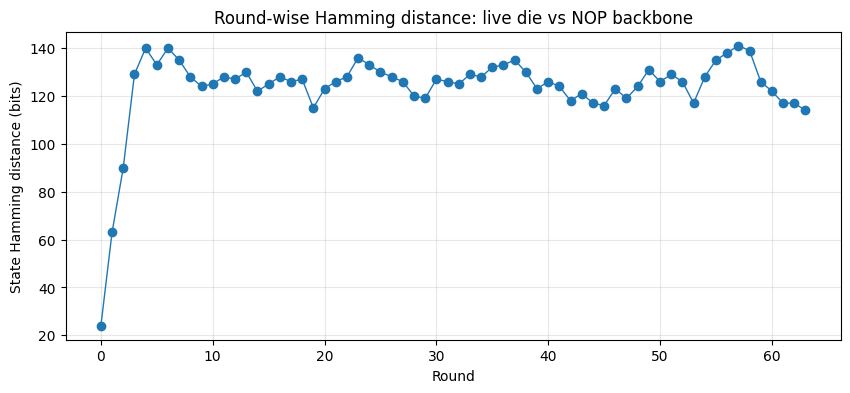

max distance: 141
round of max: 57


In [10]:

# ============================================================
# LIVE VS NOP: ROUND-WISE STATE DISTANCE
# ============================================================

def state_hamming_distance(x: Tuple[int, ...], y: Tuple[int, ...]) -> int:
    return sum(bit_count32(a ^ b) for a, b in zip(x, y))

live_vs_nop = []
for rt_live, rt_nop in zip(trace_abc["rounds"], nop_trace["rounds"]):
    live_vs_nop.append(state_hamming_distance(rt_live.state_out, rt_nop.state_out))

plt.figure(figsize=(10, 4))
plt.plot(range(64), live_vs_nop, marker="o", linewidth=1)
plt.title("Round-wise Hamming distance: live die vs NOP backbone")
plt.xlabel("Round")
plt.ylabel("State Hamming distance (bits)")
plt.grid(True, alpha=0.3)
plt.show()

print("max distance:", max(live_vs_nop))
print("round of max:", int(np.argmax(live_vs_nop)))


## 6. Nilpotent transport backbone

The paper rewrites the round map as

$$
x_{r+1} = P x_r + u_a(T1_r + T2_r) + u_e T1_r,
$$

with `P` the pure shift matrix and `u_a`, `u_e` the two seam basis vectors.

For the register ordering

$$
x_r = [a_r,b_r,c_r,d_r,e_r,f_r,g_r,h_r]^\top,
$$

the transport-only matrix is

$$
P =
\begin{bmatrix}
0&0&0&0&0&0&0&0\\
1&0&0&0&0&0&0&0\\
0&1&0&0&0&0&0&0\\
0&0&1&0&0&0&0&0\\
0&0&0&1&0&0&0&0\\
0&0&0&0&1&0&0&0\\
0&0&0&0&0&1&0&0\\
0&0&0&0&0&0&1&0
\end{bmatrix}.
$$

This matrix is nilpotent:

$$
P^8 = 0,
$$

with rank `7`.  
So transport alone is a finite-memory sink. The die survives only because the seams are repeatedly driven.


In [11]:

# ============================================================
# NILPOTENT SHIFT MATRIX
# ============================================================

P = np.zeros((8, 8), dtype=int)
for row, col in [(1,0), (2,1), (3,2), (4,3), (5,4), (6,5), (7,6)]:
    P[row, col] = 1

ua = np.array([[1],[0],[0],[0],[0],[0],[0],[0]], dtype=int)
ue = np.array([[0],[0],[0],[0],[1],[0],[0],[0]], dtype=int)
B = np.concatenate([ua, ue], axis=1)

rows = [
    {"property": "rank(P)", "value": int(np.linalg.matrix_rank(P))},
    {"property": "P^2 zero?", "value": bool(np.all(np.linalg.matrix_power(P, 2) == 0))},
    {"property": "P^7 zero?", "value": bool(np.all(np.linalg.matrix_power(P, 7) == 0))},
    {"property": "P^8 zero?", "value": bool(np.all(np.linalg.matrix_power(P, 8) == 0))},
]

show_df(rows, title="Nilpotent transport checks")
print("P =")
print(P)


Nilpotent transport checks


,property,value
0,rank(P),7
1,P^2 zero?,False
2,P^7 zero?,False
3,P^8 zero?,True


P =
[[0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]]


Controllability rank growth from seam injections


,k,"rank([B, PB, ..., P^k B])"
0,0,2
1,1,4
2,2,6
3,3,8
4,4,8
5,5,8
6,6,8
7,7,8


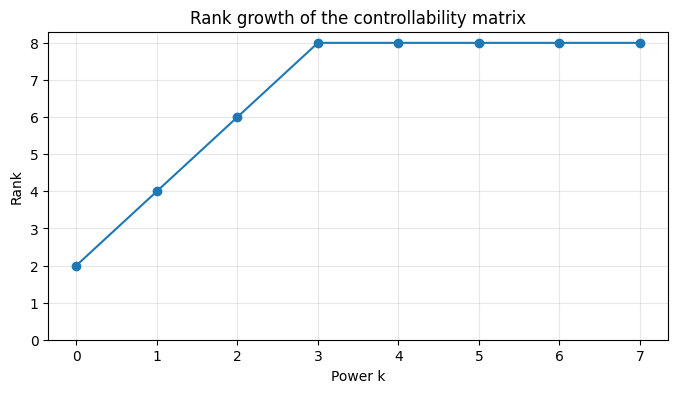

Full rank reached at k = 3


In [12]:

# ============================================================
# CONTROLLABILITY FROM THE TWO SEAMS
# ============================================================

rank_growth = []
blocks = []
for k in range(8):
    blocks.append(np.linalg.matrix_power(P, k) @ B)
    C = np.concatenate(blocks, axis=1)
    rank_growth.append(int(np.linalg.matrix_rank(C)))

rows = [{"k": k, "rank([B, PB, ..., P^k B])": rank_growth[k]} for k in range(8)]
show_df(rows, title="Controllability rank growth from seam injections")

plt.figure(figsize=(8, 4))
plt.plot(range(8), rank_growth, marker="o")
plt.title("Rank growth of the controllability matrix")
plt.xlabel("Power k")
plt.ylabel("Rank")
plt.xticks(range(8))
plt.yticks(range(0, 9))
plt.grid(True, alpha=0.3)
plt.show()

print("Full rank reached at k =", next(k for k, r in enumerate(rank_growth) if r == 8))


## 7. Carry channel dynamics

The paper reads carry as the direct digital analogue of current continuity.  
The notebook does not need that interpretation to measure it. We can directly count carry events in the local additions.

For each round we collect:

- `carry_T1`: cumulative carry activity in the five-term South Bridge sum,
- `carry_a`: carry activity in `a_{r+1} = T1 + T2`,
- `carry_e`: carry activity in `e_{r+1} = d + T1`.

This gives a concrete round-wise residue profile.


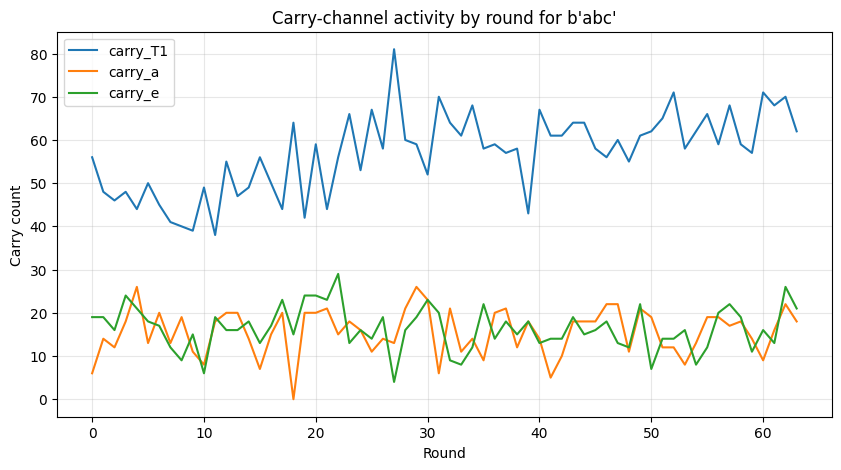

Carry-channel summary statistics


,channel,min,max,mean,std
0,carry_T1,38,81,57.015625,9.216989
1,carry_a,0,26,15.609375,5.308063
2,carry_e,4,29,16.375000,4.979646


In [13]:

# ============================================================
# CARRY-CHANNEL PROFILE
# ============================================================

rounds = trace_abc["rounds"]
carry_T1 = [rt.carry_T1 for rt in rounds]
carry_a  = [rt.carry_a for rt in rounds]
carry_e  = [rt.carry_e for rt in rounds]

plt.figure(figsize=(10, 5))
plt.plot(range(64), carry_T1, label="carry_T1")
plt.plot(range(64), carry_a, label="carry_a")
plt.plot(range(64), carry_e, label="carry_e")
plt.title("Carry-channel activity by round for b'abc'")
plt.xlabel("Round")
plt.ylabel("Carry count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

rows = []
for name, arr in [("carry_T1", carry_T1), ("carry_a", carry_a), ("carry_e", carry_e)]:
    rows.append({
        "channel": name,
        "min": int(np.min(arr)),
        "max": int(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
    })
show_df(rows, title="Carry-channel summary statistics")


In [14]:

# ============================================================
# ROUND TABLE WITH CARRY DATA
# ============================================================

rows = []
for rt in rounds[:12]:
    rows.append({
        "round": rt.round_index,
        "T1": hex32(rt.T1),
        "T2": hex32(rt.T2),
        "carry_T1": rt.carry_T1,
        "carry_a": rt.carry_a,
        "carry_e": rt.carry_e,
    })
show_df(rows, title="First 12 rounds with carry annotations")


First 12 rounds with carry annotations


,round,T1,T2,carry_T1,carry_a,carry_e
0,0,0x54da50e8,0x08909ae5,56,6,19
1,1,0x3c5f8617,0x1e0b5396,48,14,19
2,2,0x3dc18b66,0x8b01bc41,46,12,16
3,3,0xbad621e9,0x1a7ad47d,48,18,24
4,4,0xe642b678,0x1dfde3f2,44,26,21
5,5,0x16d78700,0x146a82f5,50,13,18
6,6,0xd2645c5a,0x129ea726,45,20,17
7,7,0x37148413,0x4e8bf74c,41,13,12
8,8,0x2e899322,0x5f7b5997,40,19,9
9,9,0xf1871ba1,0x9b0018ca,39,11,15


## 8. Prime-root rails

The paper states that the two fixed rail families come from prime-root irrationality:

- `H0` from the fractional parts of square roots of the first 8 primes,
- `K` from the fractional parts of cube roots of the first 64 primes.

That is not interpretive. It is exactly how the SHA-256 constants are defined, and we can verify the reconstruction directly.


In [15]:

# ============================================================
# PRIME-ROOT RAIL VERIFICATION
# ============================================================

getcontext().prec = 80

def first_primes(n: int) -> List[int]:
    primes = []
    x = 2
    while len(primes) < n:
        ok = True
        for p in primes:
            if p * p > x:
                break
            if x % p == 0:
                ok = False
                break
        if ok:
            primes.append(x)
        x += 1
    return primes

def sqrt_frac_word(p: int) -> int:
    x = Decimal(p).sqrt()
    frac = x - int(x)
    return int(frac * (1 << 32)) & M32

def cbrt_frac_word(p: int) -> int:
    x = Decimal(p) ** (Decimal(1) / Decimal(3))
    frac = x - int(x)
    return int(frac * (1 << 32)) & M32

primes8 = first_primes(8)
primes64 = first_primes(64)

derived_H = [sqrt_frac_word(p) for p in primes8]
derived_K = [cbrt_frac_word(p) for p in primes64]

rows = [
    {"family": "H0 from sqrt(primes)", "exact_match": derived_H == STD_H},
    {"family": "K from cbrt(primes)", "exact_match": derived_K == STD_K},
]
show_df(rows, title="Prime-root rail reconstruction")

first_rows = []
for i in range(8):
    first_rows.append({
        "i": i,
        "prime": primes8[i],
        "derived_H_i": hex32(derived_H[i]),
        "STD_H_i": hex32(STD_H[i]),
    })
show_df(first_rows, title="Initial rail H0 reconstruction detail")


Prime-root rail reconstruction


,family,exact_match
0,H0 from sqrt(primes),True
1,K from cbrt(primes),True


Initial rail H0 reconstruction detail


,i,prime,derived_H_i,STD_H_i
0,0,2,0x6a09e667,0x6a09e667
1,1,3,0xbb67ae85,0xbb67ae85
2,2,5,0x3c6ef372,0x3c6ef372
3,3,7,0xa54ff53a,0xa54ff53a
4,4,11,0x510e527f,0x510e527f
5,5,13,0x9b05688c,0x9b05688c
6,6,17,0x1f83d9ab,0x1f83d9ab
7,7,19,0x5be0cd19,0x5be0cd19


## 9. Diffusion / message influence experiment

The PDF text indicates that message influence grows across rounds.  
Because the exact support metric is not fully recoverable from the extracted formula text, this notebook implements a clean **proxy**:

- take a base message,
- flip one input bit,
- compute the round-wise Hamming distance between the two die states.

That is not the paper's only possible metric, but it is a direct executable measure of perturbation propagation.


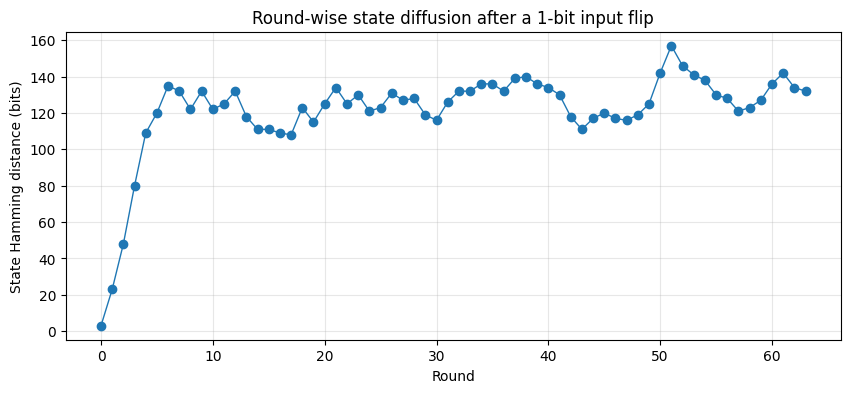

Diffusion summary


,base_message,flipped_message,max_distance_bits,round_of_max,distance_round_0,distance_round_1
0,b'abc',b'`bc',NaN,NaN,NaN,NaN
1,NaN,NaN,157.0,51.0,NaN,NaN
2,NaN,NaN,NaN,NaN,3.0,23.0


In [16]:

# ============================================================
# SINGLE-BIT FLIP DIFFUSION TEST
# ============================================================

def flip_first_bit(message: bytes) -> bytes:
    if not message:
        return b"\x80"
    return bytes([message[0] ^ 0x01]) + message[1:]

base_msg = SAMPLE_MESSAGE
flip_msg = flip_first_bit(base_msg)

trace_base = sha256_compress_trace_one_block(base_msg)
trace_flip = sha256_compress_trace_one_block(flip_msg)

distances = []
for rt_a, rt_b in zip(trace_base["rounds"], trace_flip["rounds"]):
    distances.append(state_hamming_distance(rt_a.state_out, rt_b.state_out))

plt.figure(figsize=(10, 4))
plt.plot(range(64), distances, marker="o", linewidth=1)
plt.title("Round-wise state diffusion after a 1-bit input flip")
plt.xlabel("Round")
plt.ylabel("State Hamming distance (bits)")
plt.grid(True, alpha=0.3)
plt.show()

rows = [
    {"base_message": base_msg, "flipped_message": flip_msg},
    {"max_distance_bits": int(np.max(distances)), "round_of_max": int(np.argmax(distances))},
    {"distance_round_0": int(distances[0]), "distance_round_1": int(distances[1])},
]
show_df(rows, title="Diffusion summary")


## 10. SHA-256 vs Keccak: architectural contrast table

The paper contrasts SHA-256 and Keccak as two valid engines on the same broader grammar, but with very different local topologies.

That contrast is encoded below as a direct comparison table.  
This section is descriptive rather than a new proof.


In [17]:

# ============================================================
# ARCHITECTURAL CONTRAST TABLE
# ============================================================

contrast_rows = [
    {"feature": "state geometry", "SHA-256": "8 x 32-bit working lanes", "Keccak/SHA-3": "25 x 64-bit lanes"},
    {"feature": "block / rate shape", "SHA-256": "64-byte block compression", "Keccak/SHA-3": "sponge absorb / permute / squeeze"},
    {"feature": "transport depth", "SHA-256": "64 sequential rounds", "Keccak/SHA-3": "24 permutation rounds"},
    {"feature": "fixed constants", "SHA-256": "large prime-root lattice K", "Keccak/SHA-3": "small round-constant mechanism"},
    {"feature": "local split", "SHA-256": "T1/T2 seam injection", "Keccak/SHA-3": "theta/rho/pi/chi/iota diffusion stack"},
    {"feature": "explicit NOP anchor", "SHA-256": "yes: message-free T2 ground fold", "Keccak/SHA-3": "not in the same local form"},
    {"feature": "transport interpretation", "SHA-256": "narrow, deep pipeline", "Keccak/SHA-3": "wide parallel sponge"},
]
show_df(contrast_rows, title="Architectural contrast")


Architectural contrast


,feature,SHA-256,Keccak/SHA-3
0,state geometry,8 x 32-bit working lanes,25 x 64-bit lanes
1,block / rate shape,64-byte block compression,sponge absorb / permute / squeeze
2,transport depth,64 sequential rounds,24 permutation rounds
3,fixed constants,large prime-root lattice K,small round-constant mechanism
4,local split,T1/T2 seam injection,theta/rho/pi/chi/iota diffusion stack
5,explicit NOP anchor,yes: message-free T2 ground fold,not in the same local form
6,transport interpretation,"narrow, deep pipeline",wide parallel sponge


## 11. Final synthesis

### Verified in this notebook

The following claims are now **directly established in code** for the single-block die:

1. the local SHA-256 implementation matches `hashlib`,
2. the paper's bridge split is exactly the standard `T1/T2` split,
3. the round-0 North Bridge value is

   $$
   T2_0 = 0x08909ae5,
   $$

4. the seam differential identity

   $$
   a_{r+1} - e_{r+1} \equiv T2_r - d_r \pmod{2^{32}}
   $$

   holds exactly,
5. the round-0 displacement identity

   $$
   T1_0 - T1_0^{(0)} \equiv W_0 \pmod{2^{32}}
   $$

   holds exactly,
6. the pure shift matrix `P` is nilpotent with

   $$
   \mathrm{rank}(P)=7,\qquad P^8 = 0,
   $$

7. the two seam injections generate full 8D controllability in four steps,
8. the `H0` and `K` rails reconstruct exactly from prime-root fractional parts.

### What this means locally

The die is not "just a list of instructions."  
It is a sparse transport skeleton plus two repeatedly driven nonlinear seams.

That is the strongest executable content of the paper:

- **transport alone dies,**
- **the seams keep the machine alive,**
- **the message enters through a sharply localized injection law,**
- **observable algebra survives the injection.**

### Extension points

Natural next sections to add after this notebook:

- full multi-block die instrumentation,
- backward observable walk / Glass Key cells,
- support metrics beyond Hamming influence,
- transistor-topology diagrams rendered from the seam graph,
- Keccak side-by-side instrumentation in the same formal basis.


In [18]:

# ============================================================
# EXECUTIVE SUMMARY DICTIONARY
# ============================================================

summary = {
    "digest_match_hashlib": trace_abc["digest_hex"] == hashlib.sha256(SAMPLE_MESSAGE).hexdigest(),
    "north_bridge_round0_hex": hex32(trace_abc["rounds"][0].T2),
    "round0_displacement_identity": hex32((trace_abc["rounds"][0].T1 - nop_trace["rounds"][0].T1) & M32),
    "W0_hex": hex32(trace_abc["W"][0]),
    "rank_P": int(np.linalg.matrix_rank(P)),
    "P8_is_zero": bool(np.all(np.linalg.matrix_power(P, 8) == 0)),
    "controllability_rank_sequence": rank_growth,
    "derived_H_matches": derived_H == STD_H,
    "derived_K_matches": derived_K == STD_K,
    "max_live_vs_nop_distance": int(max(live_vs_nop)),
    "max_flip_diffusion_distance": int(max(distances)),
}
summary


{'digest_match_hashlib': True,
 'north_bridge_round0_hex': '0x08909ae5',
 'round0_displacement_identity': '0x61626380',
 'W0_hex': '0x61626380',
 'rank_P': 7,
 'P8_is_zero': True,
 'controllability_rank_sequence': [2, 4, 6, 8, 8, 8, 8, 8],
 'derived_H_matches': True,
 'derived_K_matches': True,
 'max_live_vs_nop_distance': 141,
 'max_flip_diffusion_distance': 157}